In [64]:
import math

import torch
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

from utils import alpha_to_gamma, build_luts

In [65]:
t_min = 0.
t_max = 1.
vocab_size = 30522
n = 4096

In [66]:
lut_a2g, lut_g2a = build_luts(K=vocab_size)

In [67]:
_eps_t = torch.rand(n)
offset = torch.arange(n) / n
_eps_t = (_eps_t / n + offset) % 1
perm = torch.randperm(n)
_eps_t = _eps_t[perm]
tau = (t_max - t_min) * _eps_t + t_min

In [118]:
t = alpha_to_gamma(tau, lut_a2g)
# alpha = torch.nn.functional.sigmoid(torch.log(tau/(1-tau)))
# alpha = 1-torch.cos(t * torch.pi/1.85)
# snr = tau / (1 - tau)
# snr = -torch.log(1 - tau)
# alpha = torch.sqrt(snr) / (1 + torch.sqrt(snr))
# alpha = torch.sqrt(tau) / (torch.sqrt(tau) + torch.sqrt(1 -tau))
def t_to_alpha(t, C=16., p=0.4, eps=1e-9):
    # r = -torch.log1p(-t.clamp(max=1-eps)) / torch.log(torch.tensor(2., device=t.device))
    # sqrt_snr = math.sqrt(C) * r.pow(0.5 * p)
    t_max=0.999
    print(f"SNR_max={C * math.pow(-math.log(1-t_max), p)}")
    sqrt_snr = torch.sqrt(C * (-torch.log1p(-t)).pow(p))
    return sqrt_snr / (1.0 + sqrt_snr)

alpha = t_to_alpha(tau, C=20.22769546508789, p=0.43102750182151794) #C=17.6, p=0.5)#C=17.267051696777344, p=0.43035614490509033)

SNR_max=46.528999322571934


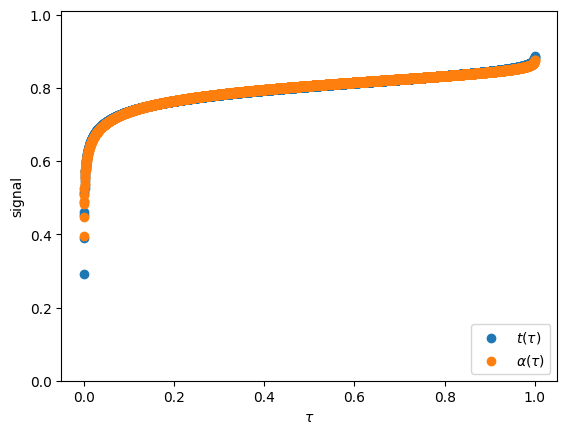

In [119]:
plt.scatter(tau, t, label=r"$t(\tau)$")
plt.scatter(tau, alpha, label=r"$\alpha(\tau)$")
plt.xlabel(r"$\tau$")
plt.ylabel("signal")
plt.ylim([0, 1.01])
plt.legend(loc="lower right")
plt.show()

const=tensor(10.7206)


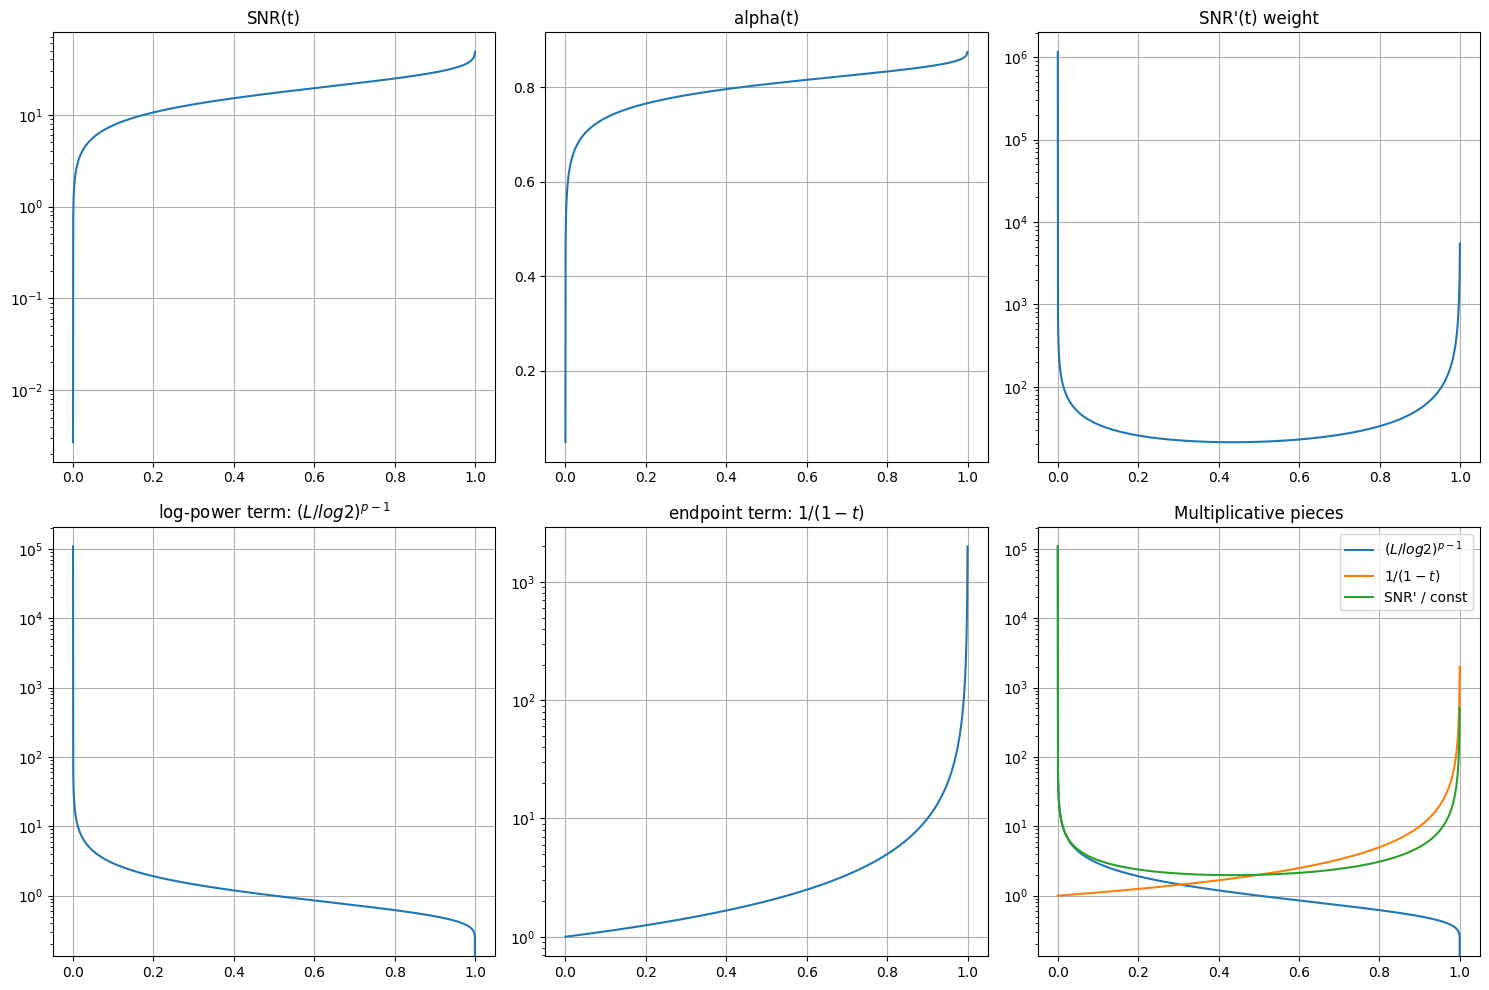

In [59]:
import torch
import matplotlib.pyplot as plt

def snr_terms(t, p=0.45, C=16.0, eps=1e-9):
    t = t.clamp(min=eps, max=1 - eps)
    print

    L0 = torch.log(torch.tensor(2.0, device=t.device, dtype=t.dtype))
    L = -torch.log1p(-t)
    r = L / L0

    const = C * p / L0
    log_power_term = r.pow(p - 1.0)
    endpoint_term = 1.0 / (1.0 - t)

    snr_prime = const * log_power_term * endpoint_term

    snr = C * r.pow(p)
    sqrt_snr = torch.sqrt(snr)
    alpha = sqrt_snr / (1.0 + sqrt_snr)
    sigma = 1.0 - alpha

    print(f"{const=}")
    
    return {
        "L": L,
        "r": r,
        "const": const,
        "log_power_term": log_power_term,
        "endpoint_term": endpoint_term,
        "snr_prime": snr_prime,
        "snr": snr,
        "alpha": alpha,
        "sigma": sigma,
    }


# ---- choose parameters ----
# p = 0.45
# C = 16.0
C = 17.267051696777344
p = 0.43035614490509033

t = torch.linspace(0, 1, 2000)
out = snr_terms(t, p=p, C=C)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(t, out["snr"])
plt.yscale("log")
plt.title("SNR(t)")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(t, out["alpha"])
plt.title("alpha(t)")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(t, out["snr_prime"])
plt.yscale("log")
plt.title("SNR'(t) weight")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(t, out["log_power_term"])
plt.yscale("log")
plt.title(r"log-power term: $(L/log2)^{p-1}$")
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(t, out["endpoint_term"])
plt.yscale("log")
plt.title(r"endpoint term: $1/(1-t)$")
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(t, out["log_power_term"], label=r"$(L/log2)^{p-1}$")
plt.plot(t, out["endpoint_term"], label=r"$1/(1-t)$")
plt.plot(t, out["snr_prime"] / out["const"], label=r"SNR' / const")
plt.yscale("log")
plt.title("Multiplicative pieces")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [109]:
def alpha_from_schedule(t, C, p):
    L = -torch.log1p(-t)
    # L0 = torch.log(torch.tensor(2.0, device=t.device))
    L0 = 1.
    snr = C * (L / L0)**p
    sqrt_snr = torch.sqrt(snr)
    return sqrt_snr / (1 + sqrt_snr)


def fit_schedule(tau, t_flm):
    C = torch.tensor(16.0, requires_grad=True)
    p = torch.tensor(0.5, requires_grad=True)

    opt = torch.optim.Adam([C, p], lr=1e-2)

    for _ in tqdm(range(10_000)):
        alpha = alpha_from_schedule(tau, C, p)

        loss = ((alpha - t_flm)**2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        # keep valid
        C.data.clamp_(1e-3, 1e3)
        p.data.clamp_(0.05, 2.0)

    return C.item(), p.item()

In [110]:
# n_points = 10_000
# tau_t = torch.linspace(0.0, 1.0, n_points)
optimized = fit_schedule(tau, alpha_to_gamma(tau, lut_a2g))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 732.21it/s]


In [111]:
optimized

(20.22769546508789, 0.43102750182151794)